In [2]:
import pandas as pd
df = pd.read_excel("../data/_Work_/_Work_battery_.xlsx")


In [3]:
df["tau_p4"] = df["CCA(A)"] * (df["내부저항(mΩ)"] ** 0.5)

In [4]:
import joblib
model = joblib.load("model.pkl")

c:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LinearRegression from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [5]:
print(df.columns)

Index(['날짜', '차량', '배터리 종류', '전압(V)', '내부저항(mΩ)', 'SOH(%)', 'CCA(A)',
       'RC(min)', '교체 여부', '메모', '증상', '테스트 결과', 'tau_p4'],
      dtype='object')


In [6]:
print(df["tau_p4"].isnull().sum())

4


In [7]:
#결측 제거
df = df.dropna(subset=["tau_p4"])

# Calibration
- SOH_real ≈ a * SOH_pred + b
- a = 기울기 (scale 조정)
- b = 절편 (offset 조정)


In [8]:
# 1. 기존 예측
df["SOH_pred"] = model.predict(df[["tau_p4"]])

# 2. 보정 모델 학습
from sklearn.linear_model import LinearRegression
cal_model = LinearRegression()
cal_model.fit(df[["SOH_pred"]], df["SOH(%)"])

# 3. 최종 예측
df["SOH_final"] = cal_model.predict(df[["SOH_pred"]])
df["SOH_final"] = df["SOH_final"].clip(0, 100)

In [9]:
print(df[["SOH(%)", "SOH_pred","SOH_final" ]].head())

   SOH(%)     SOH_pred  SOH_final
1    26.0  2689.562980  38.916583
4     0.0  1270.631382   6.678071
5     0.0   648.486949   0.000000
7    39.0  2967.011111  45.220280
8    17.0  1906.043616  21.114810


In [10]:
from sklearn.metrics import r2_score, mean_squared_error

print("Before:", r2_score(df["SOH(%)"], df["SOH_pred"]))
print("After:", r2_score(df["SOH(%)"], df["SOH_final"]))

Before: -11299.58893323997
After: 0.8200915642164908


In [11]:
import matplotlib.pyplot as plt
import numpy as np
m, b = np.polyfit(df["SOH(%)"],
                  df["SOH_final"], 1)

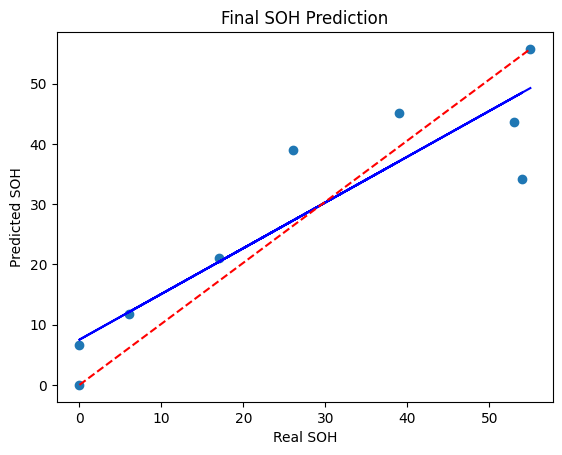

In [12]:


plt.scatter(df["SOH(%)"], df["SOH_final"])
plt.plot(df["SOH(%)"],
         m * df["SOH(%)"] + b,
         color="blue")

# 이상적인 선
plt.plot([0, max(df["SOH(%)"])], [0, max(df["SOH_final"])], 'r--', label="Ideal")
plt.xlabel("Real SOH")
plt.ylabel("Predicted SOH")
plt.title("Final SOH Prediction")
plt.show()

# 분석
Calibration 이후 모델은 R² = 0.82를 기록하며
실제 SOH와 높은 상관성을 보였다.

또한 scatter plot에서 데이터는
이상적인 y=x 선 주변에 분포하여
모델이 SOH의 변화 경향을 잘 반영함을 확인하였다.

다만 일부 구간에서 오차가 존재하며,
이는 실제 환경에서의 측정 오차 및
단순화된 feature 구성에 기인한 것으로 판단된다.



## 다음 진행 계획

배터리 SOH 예측의 정확도 향상을 위해 온도 데이터를 추가 변수로 도입할 예정이다.

NASA 데이터의 온도 정보를 활용해 기존 시상수 기반 모델에 온도를 함께 학습시키고, 공업사 데이터에는 실제 기온을 적용하여 성능 변화를 비교한다.

이를 통해 실제 환경을 반영한 보다 현실적인 SOH 예측 모델로 확장하고자 한다.